<a href="https://colab.research.google.com/github/Shahrukh2016/LangGraph_with_open_source_models/blob/master/1_Building_Short_Term_Memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
%%capture

## Setting up Ollama - A local LLM
!sudo apt-get update -qq && sudo apt-get install -y zstd -qq
!curl -fsSLs https://ollama.com/install.sh | sh
!nohup ollama serve > ollama.log 2>&1 &
!ollama pull llama3.2:1b
# !ollama pull llama3.1
# !ollama pull qwen:0.5b
# !ollama pull qwen3-embedding:0.6b

## Installing required libraries
!pip install -q langchain langchain-core langchain-classic langchain-huggingface langchain-ollama langchain-community langchain-ollama pydantic pydantic[email] grandalf pypdf pymupdf langchain_text_splitters langchain-experimental langchain-chroma chromadb --upgrade opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp langchain-pinecone langgraph

In [35]:
## Importing libraries
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, MessagesState, START, END

## Initializing model
model = ChatOllama(model = 'llama3.2:1b')
model.invoke("Hey there how are you today?")

AIMessage(content="I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here and ready to help you with any questions or topics you'd like to discuss. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2026-08-25T07:30:14.101363356Z', 'done': True, 'done_reason': 'stop', 'total_duration': 45772127166, 'load_duration': 19420875876, 'prompt_eval_count': 32, 'prompt_eval_duration': 25849594000, 'eval_count': 61, 'eval_duration': 498732000, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--01a037d2-f908-79f2-a9f7-d19dd25b6b9e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 32, 'output_tokens': 61, 'total_tokens': 93})

##### 1. Without Short Term Memory

In [40]:
def call_model(state: MessagesState):
  response = model.invoke(state['messages'])
  return {'messages' : [response]}

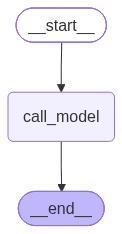

In [41]:
graph = StateGraph(MessagesState)
graph.add_node("call_model", call_model)
graph.add_edge(START, "call_model")
graph.add_edge("call_model", END)
workflow = graph.compile()
workflow

In [38]:
### Calling model

## Without short term memory
input = {
    'messages' : [{
    'role' : 'user',
    'content' : 'Hi, My name is Shahrukh'
    }]
}
workflow.invoke(input)

{'messages': [HumanMessage(content='Hi, My name is Shahrukh', additional_kwargs={}, response_metadata={}, id='8fa35465-58fd-4bb3-85cb-8cd6f1a5415e'),
  AIMessage(content="Hello Shahrukh, what's on your mind today?", additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2026-08-25T07:30:14.413227997Z', 'done': True, 'done_reason': 'stop', 'total_duration': 102872292, 'load_duration': 1499587, 'prompt_eval_count': 33, 'prompt_eval_duration': 10668000, 'eval_count': 13, 'eval_duration': 84101000, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--01a037d3-aca5-7df1-8cbc-b99c5095176b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 33, 'output_tokens': 13, 'total_tokens': 46})]}

In [39]:
## Without short term memory
input = {
    'messages' : [{
    'role' : 'user',
    'content' : 'Hi, tell me my name?'
    }]
}
workflow.invoke(input)

{'messages': [HumanMessage(content='Hi, tell me my name?', additional_kwargs={}, response_metadata={}, id='a99fd074-0823-43bf-b3ac-aa5ec2d2f0ac'),
  AIMessage(content="I don't have any information about you or your name. I'm a large language model, I don't have the ability to access or store your personal data. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name, I'd be happy to chat with you and respond accordingly.", additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2026-08-25T07:30:14.992348328Z', 'done': True, 'done_reason': 'stop', 'total_duration': 564759736, 'load_duration': 1723619, 'prompt_eval_count': 32, 'prompt_eval_duration': 11302000, 'eval_count': 78, 'eval_duration': 545394000, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--01a037d3-ad19-7a20-8cca-a5e460932fee-0', tool_calls=[], invalid_tool_calls=[],

##### 2. With Short Term Memory

In [42]:
def call_model(state: MessagesState):
  response = model.invoke(state['messages'])
  return {'messages' : [response]}

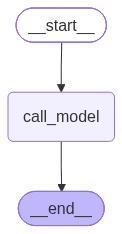

In [43]:
graph = StateGraph(MessagesState)
graph.add_node("call_model", call_model)
graph.add_edge(START, "call_model")
graph.add_edge("call_model", END)
workflow = graph.compile()
workflow

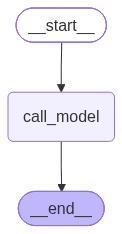

In [44]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [45]:
config = {"configurable" : {"thread_id" : "thread-1"}}

In [46]:
### Calling model

## With short term memory
input = {
    'messages' : [{
    'role' : 'user',
    'content' : 'Hi, My name is Shahrukh'
    }]
}
workflow.invoke(input, config=config)

{'messages': [HumanMessage(content='Hi, My name is Shahrukh', additional_kwargs={}, response_metadata={}, id='e05b283c-f619-42d5-8c93-bbb63f164bb9'),
  AIMessage(content="Hello Shahrukh, what's on your mind today?", additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2026-08-25T07:40:24.060749854Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3736006232, 'load_duration': 3576050158, 'prompt_eval_count': 33, 'prompt_eval_duration': 63419000, 'eval_count': 13, 'eval_duration': 93498000, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--01a037dc-ebe2-7a52-b5d7-683dd6c1577a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 33, 'output_tokens': 13, 'total_tokens': 46})]}

In [48]:
## With short term memory
input = {
    'messages' : [{
    'role' : 'user',
    'content' : 'Hi, tell me my name?'
    }]
}
workflow.invoke(input,config=config)

{'messages': [HumanMessage(content='Hi, My name is Shahrukh', additional_kwargs={}, response_metadata={}, id='e05b283c-f619-42d5-8c93-bbb63f164bb9'),
  AIMessage(content="Hello Shahrukh, what's on your mind today?", additional_kwargs={}, response_metadata={'model': 'llama3.2:1b', 'created_at': '2026-08-25T07:40:24.060749854Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3736006232, 'load_duration': 3576050158, 'prompt_eval_count': 33, 'prompt_eval_duration': 63419000, 'eval_count': 13, 'eval_duration': 93498000, 'logprobs': None, 'model_name': 'llama3.2:1b', 'model_provider': 'ollama'}, id='lc_run--01a037dc-ebe2-7a52-b5d7-683dd6c1577a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 33, 'output_tokens': 13, 'total_tokens': 46}),
  HumanMessage(content='Hi, tell me my name?', additional_kwargs={}, response_metadata={}, id='7e5fa18a-dd6a-4808-aa4b-d6bea0b62312'),
  AIMessage(content='Your name is Shahrukh.', additional_kwargs={}, response_metadata={'mo

In [54]:
snap = workflow.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
  print("-", type(m). __name__, ":", m.content)

- HumanMessage : Hi, My name is Shahrukh
- AIMessage : Hello Shahrukh, what's on your mind today?
- HumanMessage : Hi, tell me my name?
- AIMessage : Your name is Shahrukh.
